# Bandit Algorithm Implementation and Evaluation Notebook

### Package and modul imports

Let us first import all necessary libraries and modules to run our experiments. The three different bandit algorithms are imported from the src directory.

In [10]:
import numpy as np
import matplotlib as plt
from src.bernouilli_bandit import BernoulliBandit
from src.thompson_sampling import ThompsonSampling
from src.epsilon_greedy import EpsilonGreedy
from src.upper_confidence_bound import UCB1
import matplotlib.pyplot as plt

### Core Experiment Function

We can now write a function to run one bandit experiment. The function runs a given bandit algorithm for a set number of steps. At each step, the algorithm chooses an arm, gets a reward from the bandit and subsequently updates what it has learned so far. While it runs, the function keeps track of the rewards collected and whether the best arm was picked at each step. These results are then returned so they can be analyzed and plotted later for the paper.

In [11]:
def run_experiment(bandit, algo, steps):
    rewards = np.zeros(steps)
    optimal = np.zeros(steps)

    best_arm = np.argmax(bandit.probs)

    for t in range(steps):
        arm = algo.select_arm()
        reward = bandit.pull(arm)
        algo.update(arm, reward)

        rewards[t] = reward
        optimal[t] = (arm == best_arm)

    return rewards, optimal

Now we can compare multiple bandit algorithms by running each one on the same problem (reward structure). For each algorithm, we track the reward at every step, the cumulative reward over time and also how often the optimal arm is selected.

In [12]:
def compare_algorithms(bandit, algorithms, steps=5000):
    results = {}

    for name, algo in algorithms.items():
        rewards, optimal = run_experiment(bandit, algo, steps)
        results[name] = {
            "rewards": rewards,
            "cumulative": rewards.cumsum(),
            "optimal_rate": optimal.cumsum() / (np.arange(1, steps+1))
        }
    
    return results

### Multiple Runs Aggregation Function

Now we can make our evaluation more robust by running several independent experiments and averaging the results. Each run starts with fresh instances of the algorithms to ensure independence. The function then computes the mean performance along with the standard deviation.

In [13]:
# Function to run multiple different experiments and average the results
def run_multiple_experiments(bandit_probs, algorithms, steps=5000, num_runs=50):
    all_results = {name: {"cumulative": [], "optimal_rate": []} for name in algorithms.keys()}
    
    for run in range(num_runs):
        bandit = BernoulliBandit(bandit_probs)
        # Reinitialize algorithms for each run based on the passed algorithms
        fresh_algos = {}
        for name, algo in algorithms.items():
            if name == "Epsilon-Greedy":
                fresh_algos[name] = EpsilonGreedy(k=len(bandit_probs), epsilon=algo.epsilon)
            elif name == "UCB1":
                fresh_algos[name] = UCB1(k=len(bandit_probs))
            elif name == "Thompson":
                fresh_algos[name] = ThompsonSampling(k=len(bandit_probs))
        
        results = compare_algorithms(bandit, fresh_algos, steps)
        
        for name, data in results.items():
            all_results[name]["cumulative"].append(data["cumulative"])
            all_results[name]["optimal_rate"].append(data["optimal_rate"])
    
    # Averaging the results
    averaged_results = {}
    for name in algorithms.keys():
        averaged_results[name] = {
            "cumulative": np.mean(all_results[name]["cumulative"], axis=0),
            "cumulative_std": np.std(all_results[name]["cumulative"], axis=0),
            "optimal_rate": np.mean(all_results[name]["optimal_rate"], axis=0),
            "optimal_rate_std": np.std(all_results[name]["optimal_rate"], axis=0)
        }
    
    return averaged_results

### Bandit Configuration Setup and Main Experiments

Here, we define the experimental setup and execute the main experiments. We test the algorithms on three different difficulty levels: Easy (large differences in rewards), Medium (moderate differences), and Hard (small differences where the exploration–exploitation trade-off becomes more challenging). The results are then printed and displayed in three plots.

Testing on Different Bandit Configurations

Easy Configuration: [0.1, 0.5, 0.9]

Algorithm            Final Reward    Optimal Rate    Final Regret   
-----------------------------------------------------------------
Epsilon-Greedy       4276.02         0.9253          223.98         
UCB1                 4452.20         0.9789          47.80          
Thompson             4491.22         0.9971          8.78           


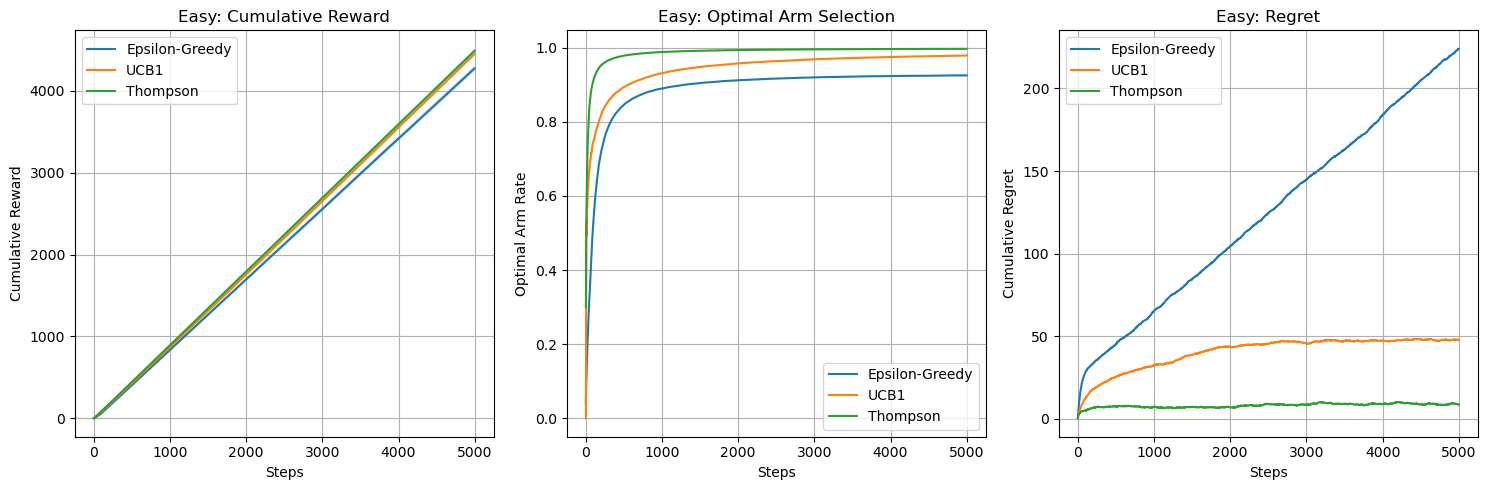


Medium Configuration: [0.3, 0.5, 0.7]

Algorithm            Final Reward    Optimal Rate    Final Regret   
-----------------------------------------------------------------
Epsilon-Greedy       3380.34         0.9207          119.66         
UCB1                 3406.90         0.9338          93.10          
Thompson             3493.82         0.9886          6.18           


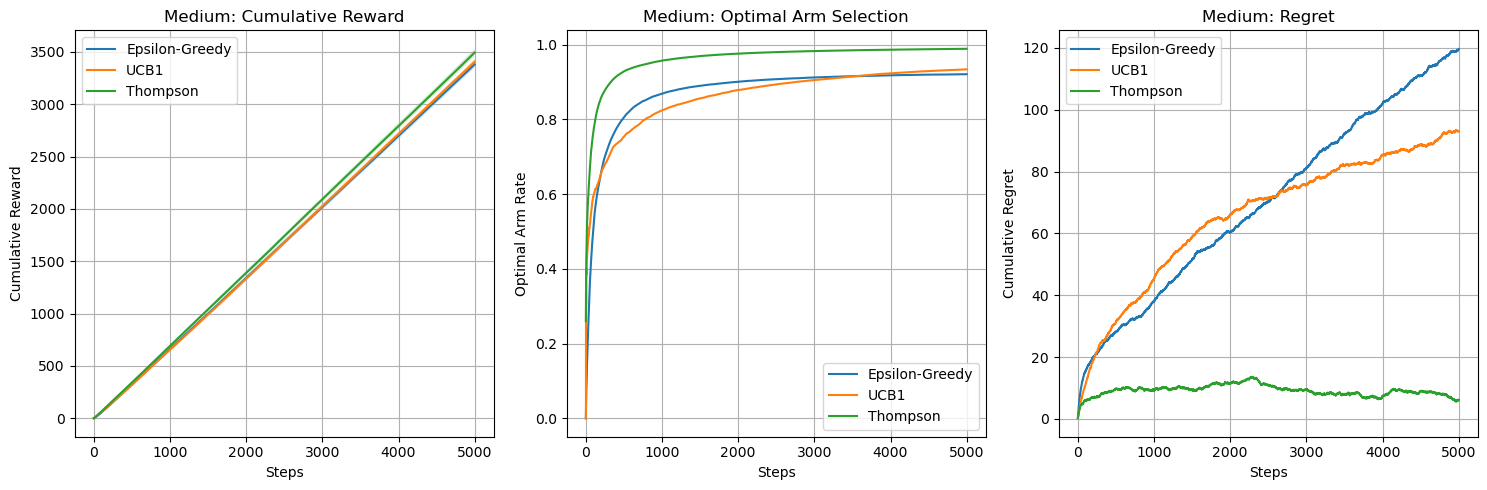


Hard Configuration: [0.48, 0.5, 0.52]

Algorithm            Final Reward    Optimal Rate    Final Regret   
-----------------------------------------------------------------
Epsilon-Greedy       2543.18         0.5991          56.82          
UCB1                 2524.46         0.4693          75.54          
Thompson             2550.02         0.6891          49.98          


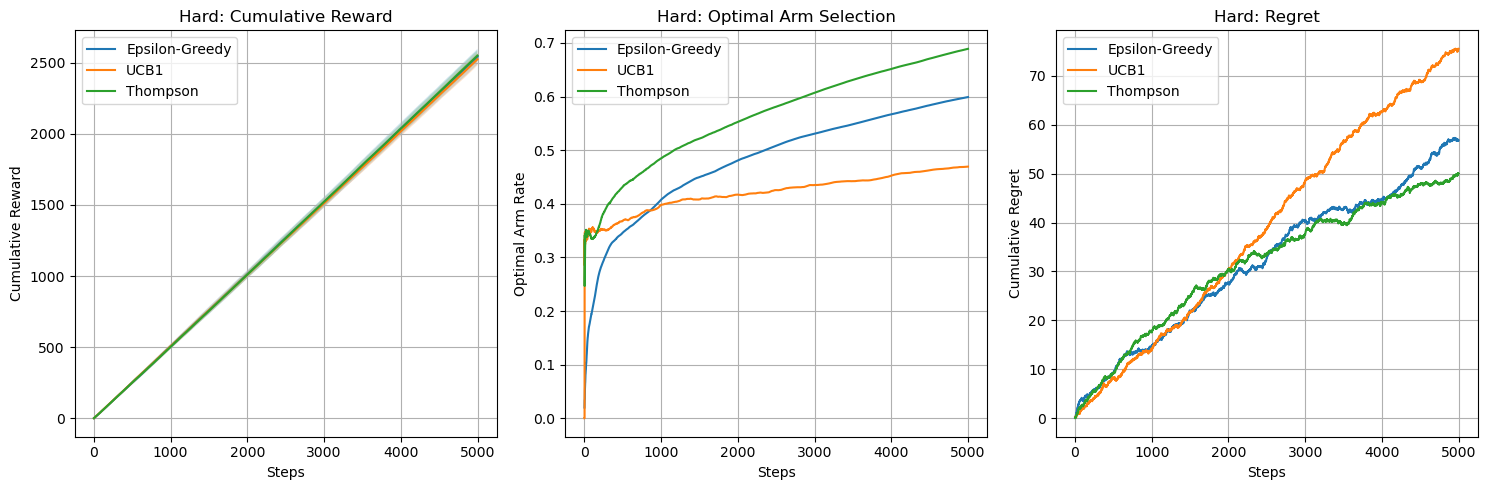

In [14]:
# Testing with different bandit configurations
bandit_configs = {
    "Easy": [0.1, 0.5, 0.9],
    "Medium": [0.3, 0.5, 0.7],
    "Hard": [0.48, 0.50, 0.52]
}

# Setting the hyperparameter for sensitivity analysis
epsilon_values = [0.01, 0.05, 0.1, 0.15, 0.2]

# Calculate regret
def calculate_regret(results, best_prob, steps):
    for name, data in results.items():
        expected_optimal = best_prob * np.arange(1, steps+1)
        data["regret"] = expected_optimal - data["cumulative"]
    return results

# Run experiments on different bandit configurations
print("=" * 60)
print("Testing on Different Bandit Configurations")
print("=" * 60)

for config_name, probs in bandit_configs.items():
    print(f"\n{config_name} Configuration: {probs}")
    algos = {
        "Epsilon-Greedy": EpsilonGreedy(k=len(probs), epsilon=0.1),
        "UCB1": UCB1(k=len(probs)),
        "Thompson": ThompsonSampling(k=len(probs))
    }
    
    avg_results = run_multiple_experiments(probs, algos, steps=5000, num_runs=50)
    avg_results = calculate_regret(avg_results, max(probs), 5000)
    
    # Printting final results
    print(f"\n{'Algorithm':<20} {'Final Reward':<15} {'Optimal Rate':<15} {'Final Regret':<15}")
    print("-" * 65)
    for name, data in avg_results.items():
        final_reward = data["cumulative"][-1]
        final_optimal_rate = data["optimal_rate"][-1]
        final_regret = data["regret"][-1]
        print(f"{name:<20} {final_reward:<15.2f} {final_optimal_rate:<15.4f} {final_regret:<15.2f}")
    
    # Plot results with confidence intervals
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    for name, data in avg_results.items():
        plt.plot(data["cumulative"], label=name)
        plt.fill_between(range(5000), 
                        data["cumulative"] - data["cumulative_std"],
                        data["cumulative"] + data["cumulative_std"],
                        alpha=0.2)
    plt.xlabel("Steps")
    plt.ylabel("Cumulative Reward")
    plt.title(f"{config_name}: Cumulative Reward")
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 3, 2)
    for name, data in avg_results.items():
        plt.plot(data["optimal_rate"], label=name)
    plt.xlabel("Steps")
    plt.ylabel("Optimal Arm Rate")
    plt.title(f"{config_name}: Optimal Arm Selection")
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 3, 3)
    for name, data in avg_results.items():
        plt.plot(data["regret"], label=name)
    plt.xlabel("Steps")
    plt.ylabel("Cumulative Regret")
    plt.title(f"{config_name}: Regret")
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.savefig(f"plots/{config_name}_bandit_comparison.png", dpi=300, bbox_inches='tight')
    plt.show()

### Epsilon Sensitivity Analysis

In our final section, we look at how the choice of the epsilon parameter impacts the performance of the Epsilon-Greedy algorithm. We test values ranging from 0.01 (mostly exploitation) to 0.2 (more exploration) to highlight the trade-off.


Epsilon-Greedy Sensitivity Analysis


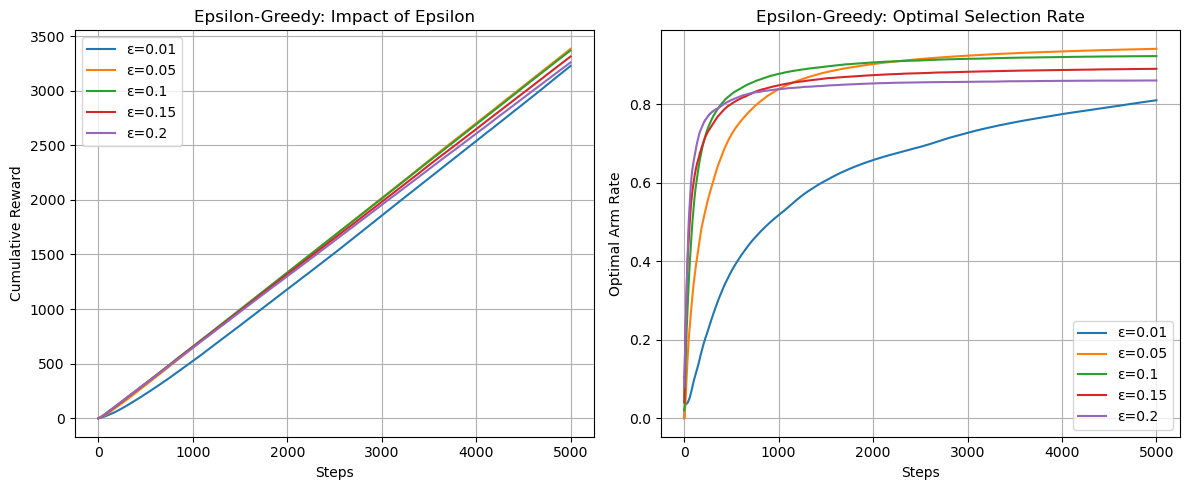

In [15]:
# Epsilon sensitivity analysis
print("\n" + "=" * 60)
print("Epsilon-Greedy Sensitivity Analysis")
print("=" * 60)

bandit_probs = [0.2, 0.5, 0.7]
epsilon_results = {}

for eps in epsilon_values:
    algos = {"Epsilon-Greedy": EpsilonGreedy(k=3, epsilon=eps)}
    avg_results = run_multiple_experiments(bandit_probs, algos, steps=5000, num_runs=50)
    epsilon_results[f"ε={eps}"] = avg_results["Epsilon-Greedy"]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for name, data in epsilon_results.items():
    plt.plot(data["cumulative"], label=name)
plt.xlabel("Steps")
plt.ylabel("Cumulative Reward")
plt.title("Epsilon-Greedy: Impact of Epsilon")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
for name, data in epsilon_results.items():
    plt.plot(data["optimal_rate"], label=name)
plt.xlabel("Steps")
plt.ylabel("Optimal Arm Rate")
plt.title("Epsilon-Greedy: Optimal Selection Rate")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("plots/epsilon_sensitivity_analysis.png", dpi=300, bbox_inches='tight')
plt.show()